950 V: mean = 1.5214e-08, sigma = 3.2237e-08
1000 V: mean = 3.6614e-08, sigma = 4.7910e-08
1100 V: mean = 1.0755e-07, sigma = 4.1492e-08
1150 V: mean = 1.3395e-07, sigma = 4.4845e-08
1200 V: mean = 2.9402e-07, sigma = 6.9695e-08
1250 V: mean = 5.6579e-07, sigma = 1.0367e-07
1300 V: mean = 6.5764e-07, sigma = 1.8961e-07
1325 V: mean = 1.0216e-06, sigma = 2.3470e-07
1350 V: mean = 1.3709e-06, sigma = 2.9836e-07
1375 V: mean = 1.6515e-06, sigma = 4.3845e-07
1400 V: mean = 2.3080e-06, sigma = 4.7924e-07
1425 V: mean = 2.8936e-06, sigma = 5.9950e-07
1450 V: mean = 4.5186e-06, sigma = 7.2543e-07
1475 V: mean = 5.5182e-06, sigma = 8.9435e-07
1500 V: mean = 7.9203e-06, sigma = 1.0988e-06
1550 V: mean = 1.1305e-05, sigma = 1.7299e-06
1600 V: mean = 1.8798e-05, sigma = 2.4408e-06


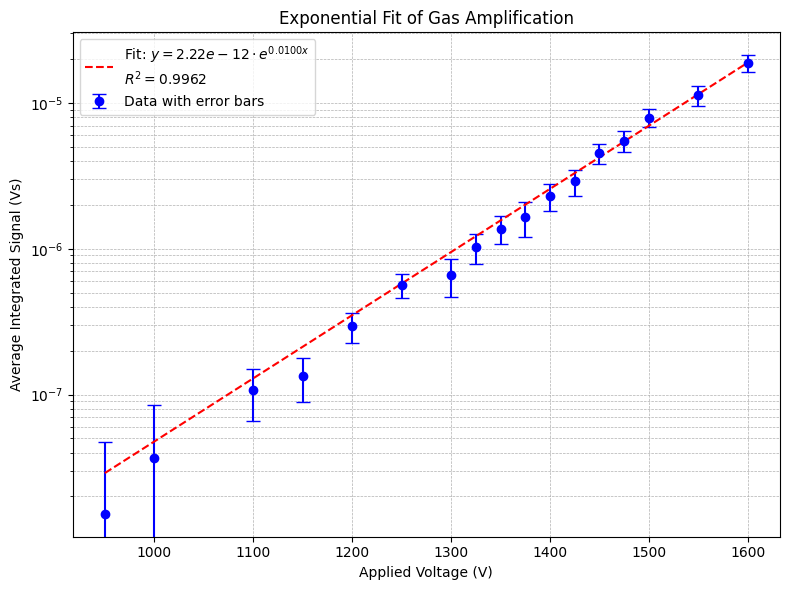

Fitted Equation: y = 2.22e-12 * exp(0.0100 * x)
R^2 = 0.9962


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# === Part 1: Calculate average and standard deviation for each voltage ===

folder_path_task = "1a"
folder_path_voltage = [950, 1000, 1100, 1150, 1200, 1250, 1300, 1325, 1350, 1375,
                       1400, 1425, 1450, 1475, 1500, 1550, 1600]

average_peaks = []
sigma_peaks = []

for voltage in folder_path_voltage:
    file_name = f"{folder_path_task}_integrated_signal_{voltage}V.csv"
    file_path = os.path.join(folder_path_task, file_name)

    try:
        # Read the CSV file for the given voltage
        df = pd.read_csv(file_path)

        # Check if the column with integrated signal exists
        if 'integrated_signal_Vs' in df.columns:
            values = df['integrated_signal_Vs']
        else:
            raise ValueError(f"Column 'integrated_signal_Vs' not found in {file_name}")

        # Convert values to numeric, coercing errors to NaN
        values = pd.to_numeric(values, errors='coerce')

        # Calculate mean ignoring NaNs
        avg = np.nanmean(values)
        # Calculate sample standard deviation ignoring NaNs (ddof=1 for sample std)
        sigma = np.nanstd(values, ddof=1)

        average_peaks.append(avg)
        sigma_peaks.append(sigma)

        print(f"{voltage} V: mean = {avg:.4e}, sigma = {sigma:.4e}")

    except Exception as e:
        # Handle any errors by appending NaN to maintain list length
        print(f"Error reading {file_name}: {e}")
        average_peaks.append(np.nan)
        sigma_peaks.append(np.nan)

# Convert lists to numpy arrays for fitting
x = np.array(folder_path_voltage)
y = np.array(average_peaks)
yerr = np.array(sigma_peaks)

# Remove any points where mean or sigma is NaN (cannot fit with NaN)
mask = ~np.isnan(y) & ~np.isnan(yerr)
x = x[mask]
y = y[mask]
yerr = yerr[mask]

# === Part 2: Fit an exponential model to the data and plot with error bars ===

# Define the exponential fitting function y = K * exp(C * x)
def exp_func(x, K, C):
    return K * np.exp(C * x)

# Perform curve fitting with initial parameter guesses
params, _ = curve_fit(exp_func, x, y, p0=(1e-9, 0.01))
K, C = params

# Calculate fitted y-values from the model
y_fit = exp_func(x, K, C)

# Calculate coefficient of determination (R²) to evaluate fit quality
residuals = y - y_fit
ss_res = np.sum(residuals**2)                # Residual sum of squares
ss_tot = np.sum((y - np.mean(y))**2)         # Total sum of squares
r_squared = 1 - (ss_res / ss_tot)

# Plot the data with error bars and the fitted exponential curve
plt.figure(figsize=(8, 6))
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=5, label='Data with error bars', color='blue')
plt.plot(x, y_fit, label=fr'Fit: $y = {K:.2e} \cdot e^{{{C:.4f}x}}$' + f'\n$R^2 = {r_squared:.4f}$',
         color='red', linestyle='--')

plt.xlabel('Applied Voltage (V)')
plt.ylabel('Average Integrated Signal (Vs)')
plt.title('Exponential Fit of Gas Amplification')
plt.yscale('log')  # Use log scale on y-axis for better visualization of exponential behavior
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Print the fitting parameters and R² value
print(f"Fitted Equation: y = {K:.2e} * exp({C:.4f} * x)")
print(f"R^2 = {r_squared:.4f}")


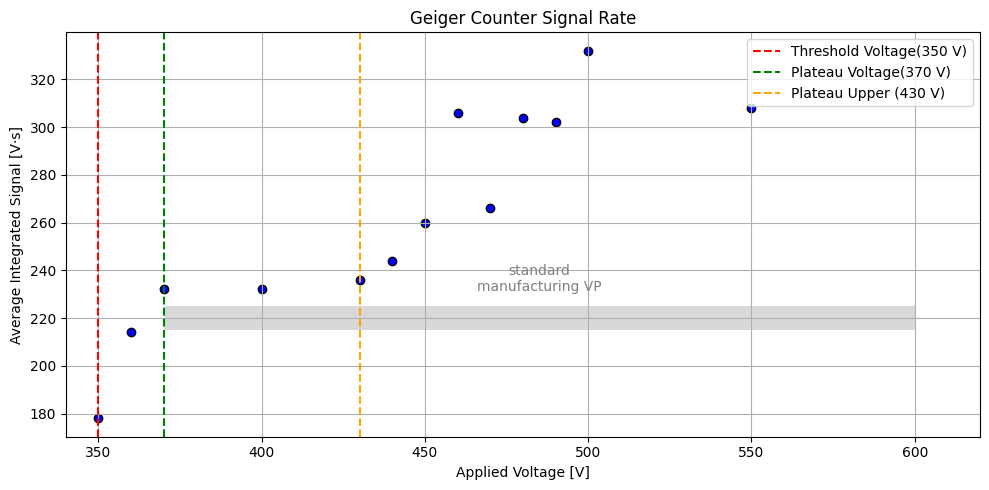

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

# Read the CSV file
df = pd.read_csv('2a_signal_rate-Copy1.csv')

# Extract x and y values
x = df['applied_voltage_V'].values
y = df['average_number_of_signals_per_second'].values

# Create the plot with specified figure size
fig, ax = plt.subplots(figsize=(10, 5))

# Scatter plot of the data points
ax.scatter(x, y, color='blue', edgecolor='black')

# Set labels and title
ax.set_xlabel("Applied Voltage [V]")
ax.set_ylabel("Average Integrated Signal [V·s]")
ax.set_title("Geiger Counter Signal Rate")

# Enable grid
ax.grid(True)

# Draw vertical dashed lines at specified voltages with labels
ax.axvline(x=350, color='red', linestyle='--', linewidth=1.5, label='Threshold Voltage(350 V)')
ax.axvline(x=370, color='green', linestyle='--', linewidth=1.5, label='Plateau Voltage(370 V)')
ax.axvline(x=430, color='orange', linestyle='--', linewidth=1.5, label='Plateau Upper (430 V)')

# Set y position and height for shaded region
y_pos = 220
height = 10 

# Add a shaded horizontal rectangle starting at x=370 with length 230 (no arrow)
rect1 = patches.Rectangle((370, y_pos - height/2), 230, height, linewidth=0, 
                          edgecolor=None, facecolor='gray', alpha=0.3)
ax.add_patch(rect1)

# Add label text above the shaded rectangle
ax.text(370 + 230/2, y_pos + height, 'standard\nmanufacturing VP', 
        color='gray', fontsize=10, ha='center', va='bottom')

# Set x-axis limits, left automatic, right set to 620
ax.set_xlim(right=620)

# Ensure output directory exists
os.makedirs("2a", exist_ok=True)

# Adjust layout, save the figure, add legend, and show plot
plt.tight_layout()
plt.savefig("2a/2a_signal_rate.png", dpi=300)
ax.legend()
plt.show()

